In [2]:
import seaborn as sns
import numpy as np

In [3]:
iris = sns.load_dataset('iris')

In [ ]:
# univariate: IQR. non-parametric
quartiles = np.percentile(iris['sepal_width'], [25,50,75])
IQR = quartiles[2] - quartiles[0]
max_whisker = quartiles[2] + 1.5*IQR
min_whisker = quartiles[0] - 1.5*IQR

mask = ( (iris['sepal_width'] > max_whisker) | (iris['sepal_width'] < min_whisker) ) # mask outliers
# sns.boxplot(data=iris)

outliers = iris[mask]
outliers = iris[mask]['sepal_width']
outliers

15    4.4
32    4.1
33    4.2
60    2.0
Name: sepal_width, dtype: float64

<Axes: >

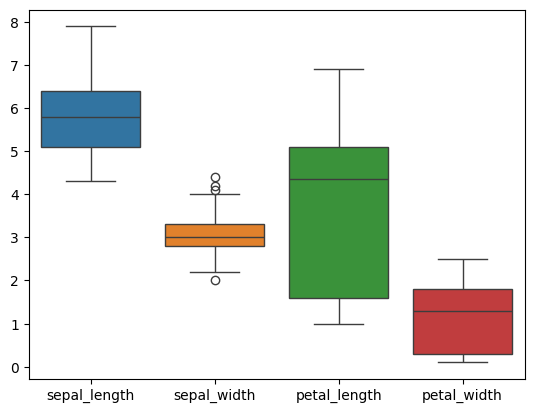

In [9]:
sns.boxplot(data=iris)

$$X_i \sim N(\mu, \sigma^2)$$

$$Z = \frac{X - \mu}{\sigma}$$

Estimadores:

$\hat{\mu} = \sum \frac{X_i}{n}$

$\hat{\sigma^2} = \frac{1}{n-1} \sum (X_i-\bar{X})^2 = S^2$

In [10]:
iris['sepal_width'].mean()

np.float64(3.0573333333333337)

In [15]:
import scipy.stats as stats
X = iris['sepal_width']
Z = stats.zscore(X)
# Z.mean() ~ casi cero
# np.var(Z) ~ casi uno
Z

array([ 1.01900435, -0.13197948,  0.32841405,  0.09821729,  1.24920112,
        1.93979142,  0.78880759,  0.78880759, -0.36217625,  0.09821729,
        1.47939788,  0.78880759, -0.13197948, -0.13197948,  2.16998818,
        3.09077525,  1.93979142,  1.01900435,  1.70959465,  1.70959465,
        0.78880759,  1.47939788,  1.24920112,  0.55861082,  0.78880759,
       -0.13197948,  0.78880759,  1.01900435,  0.78880759,  0.32841405,
        0.09821729,  0.78880759,  2.40018495,  2.63038172,  0.09821729,
        0.32841405,  1.01900435,  1.24920112, -0.13197948,  0.78880759,
        1.01900435, -1.74335684,  0.32841405,  1.01900435,  1.70959465,
       -0.13197948,  1.70959465,  0.32841405,  1.47939788,  0.55861082,
        0.32841405,  0.32841405,  0.09821729, -1.74335684, -0.59237301,
       -0.59237301,  0.55861082, -1.51316008, -0.36217625, -0.82256978,
       -2.43394714, -0.13197948, -1.97355361, -0.36217625, -0.36217625,
        0.09821729, -0.13197948, -0.82256978, -1.97355361, -1.28

multivariate outliers detection

Mahalanobis distance = $d_M$ = $\sqrt{(x-\mu)^T \sum (x-\mu)}$

Mahalanobis depth = $\frac{1}{1+{d_M}^2}$

array([0.37640886, 0.42044511, 0.33932939, 0.30525802, 0.29968603,
       0.20577473, 0.27404704, 0.40039067, 0.22802931, 0.43331048,
       0.30098592, 0.33181419, 0.37341181, 0.21633244, 0.17389857,
       0.09443419, 0.20577473, 0.37640886, 0.25487637, 0.22628867,
       0.5486936 , 0.26851515, 0.22547563, 0.49528175, 0.33181419,
       0.47424159, 0.40039067, 0.40327683, 0.4760803 , 0.33932939,
       0.38450592, 0.5486936 , 0.14261906, 0.12609602, 0.43331048,
       0.47889001, 0.47007118, 0.28036932, 0.23957466, 0.43780232,
       0.34922788, 0.13431849, 0.24547167, 0.34922788, 0.22628867,
       0.37341181, 0.22628867, 0.30369158, 0.29183762, 0.4466024 ,
       0.31144202, 0.61594815, 0.37009431, 0.2257179 , 0.53039013,
       0.70874746, 0.58803159, 0.19767002, 0.5246017 , 0.40730734,
       0.11548727, 0.98012064, 0.20421835, 0.83040689, 0.80216803,
       0.47022395, 0.89678768, 0.58851281, 0.20261251, 0.35119645,
       0.89323624, 0.70923333, 0.35583792, 0.70923333, 0.65100

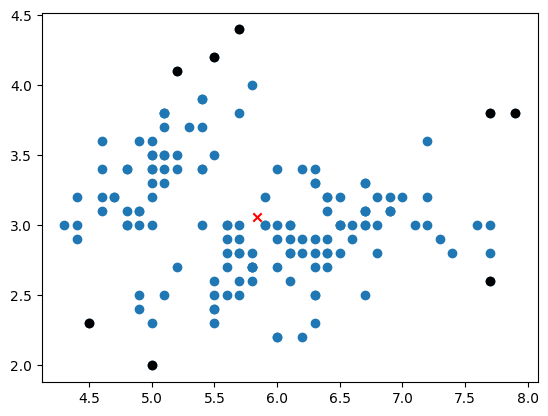

In [4]:
import matplotlib.pyplot as plt
import numpy as np

X = np.array(iris[['sepal_length', 'sepal_width']])

mu = np.mean(X, axis=0)
sigma = np.cov(X, ddof=0, rowvar=False)
sigma_inv = np.linalg.inv(sigma)
centre = X - mu
# Maha_distance = np.sqrt(np.dot(np.dot(centre.T , sigma_inv), centre))
Maha_distance = np.sqrt(np.sum((centre@sigma_inv)*centre, axis=1))
# print(Maha_distance)
Maha_depth = 1 / (1+Maha_distance**2)
# print(Maha_depth)
mask_outliers = np.percentile(Maha_depth,5) > Maha_depth
outliers = X[mask_outliers]

plt.scatter(X[:,0], X[:,1])
plt.scatter(mu[0], mu[1], marker='x', color='red')
plt.scatter(outliers[:,0], outliers[:,1], color='black')

np.percentile(Maha_depth,5)
Maha_depth

In [5]:
def calcular_mcd_manual(X, fraction=0.75, max_iter=20, tol=1e-5):
    """
    Calcula el Determinante de Covarianza Mínimo (MCD) de forma manual.
    X: Matriz de datos de tamaño (n_muestras, n_variables)
    fraction: Porcentaje de datos (h) a conservar (entre 0.5 y 1.0)
    """
    n, p = X.shape
    h = int(np.floor(n * fraction))
    
    # 1. PASO INICIAL: Seleccionar un subconjunto aleatorio inicial de tamaño 'h'
    # Nota: Para asegurar reproducibilidad usamos una semilla
    np.random.seed(42) 
    indices_actuales = np.random.choice(n, size=h, replace=False)
    
    det_anterior = float('inf')
    
    for _ in range(max_iter):
        # Tomar las filas del subconjunto actual
        X_sub = X[indices_actuales]
        
        # 2. CALCULAR ESTIMADORES CLÁSICOS del subconjunto
        # Media por columna
        media = np.mean(X_sub, axis=0)
        print(media)
        # Matriz de covarianza (ddof=1 para estimador insesgado)
        cov = np.cov(X_sub, rowvar=False)
        
        # Calcular el determinante actual
        det_actual = np.linalg.det(cov)
        
        # Condición de parada: Si el determinante ya no disminuye
        if np.abs(det_anterior - det_actual) < tol:
            break
            
        det_anterior = det_actual
        
        # 3. APLICAR EL PASO-C (Concentración)
        # Inversa de la matriz de covarianza para Mahalanobis
        inv_cov = np.linalg.inv(cov)
        
        # Calcular la distancia de Mahalanobis para TODAS las n filas de la matriz original X
        distancias = []
        for i in range(n):
            diferencia = X[i] - media
            # Fórmula: d^2 = (x - mu)^T * Sigma^-1 * (x - mu)
            d2 = diferencia.T @ inv_cov @ diferencia
            distancias.append(d2)
            
        distancias = np.array(distancias)
        
        # 4. ORDENAR Y SELECCIONAR las 'h' filas con menor distancia
        indices_actuales = np.argsort(distancias)[:h]
        
    # 5. AJUSTE DE CONSISTENCIA FINAL (Factor de escala aproximado para distribución normal)
    # Factor estándar que compensa la pérdida de varianza por recortar los datos
    factor_consistencia = 1.0 / (1.0 - (2.0 / h)) # Aproximación simple
    cov_robusta = cov * factor_consistencia
    
    return media, cov_robusta, indices_actuales, distancias

media_robusta, cov_robusta, filas_limpias, distancias_finales = calcular_mcd_manual(X, fraction=0.9)

[5.81037037 3.07185185]
[5.77851852 3.04074074]
[5.78814815 3.03925926]
[5.78814815 3.03925926]
